## 1. Data Preparation


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter
from scipy.integrate import trapezoid
import seaborn as sns
import matplotlib.patches as mpatches
import pickle
from tqdm.auto import tqdm

from utils_load_data import *
from utils_trajectories import *

# ---- Paths ----
save_directory = r'C:\Users\PenPen\Desktop\Ferret\Code\Results'

# ---- Parameters ----
dt = 0.005
t_pre, t_post = 0.3, 0.3  # PSTH window around each event
time = np.arange(-t_pre, t_post + dt, dt)
spike_sorted = True

# ---- Plotting style ----
mpl.rcdefaults()
plt.rcParams.update({
    'font.size':        7,
    'axes.linewidth':   0.5,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.major.width':0.5,
    'ytick.major.width':0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

print("Imports and config ready.")

Imports and config ready.


In [3]:
# ---- Load data ----
# MP1 = playback sessions, MP2 = mapping_change_only sessions

files = ['SKIEUR_hs_0']

def load_dataset(session_type, spike_sorted, dt):
    """Load pre-pickled neural + feature data for a given session type."""
    n_data_all, f_data_all = [], []
    suffix = "_ss" if spike_sorted else ""
    for file in files:
        path = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_data{suffix}"
        with open(path, "rb") as fp:
            n_data_all.append(pickle.load(fp))
        path_feat = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_feature{suffix}"
        with open(path_feat, "rb") as fp:
            f_data_all.append(pickle.load(fp))
    return n_data_all, f_data_all

n_data_all_mp2, f_data_all_mp2 = load_dataset('mapping_change_only', spike_sorted, dt)
n_data_all_mp1, f_data_all_mp1 = load_dataset('playback', spike_sorted, dt)

print(f"MP1 (playback): {len(n_data_all_mp1[0])} sessions loaded")
print(f"MP2 (mapping_change_only): {len(n_data_all_mp2[0])} sessions loaded")

MP1 (playback): 14 sessions loaded
MP2 (mapping_change_only): 33 sessions loaded


In [4]:
# ---- Preprocess -> Split -> Extract trajectories -> build_traj ----
# n_data_all_mp1 is [list_of_session_arrays] — take [0] for the single-file case
n_pre = int(t_pre/dt - 1)

# Toggle: force equal session count between MP1 and MP2
FORCE_EQUAL = 1
n_mp1 = len(n_data_all_mp1[0])
n_mp2 = len(n_data_all_mp2[0])
n_use_mp1 = n_mp1
n_use_mp2 = n_mp2
if FORCE_EQUAL:
    n_min = min(n_mp1, n_mp2)
    n_use_mp1 = n_min
    n_use_mp2 = n_min
    print(f"FORCE_EQUAL=1  MP1={n_mp1} -> {n_min}, MP2={n_mp2} -> {n_min}")
else:
    print(f"FORCE_EQUAL=0  MP1={n_mp1}, MP2={n_mp2} (all sessions)")

data_pairs = [
    ('MP1', (n_data_all_mp1[0][:n_use_mp1], f_data_all_mp1[0][:n_use_mp1])),
    ('MP2', (n_data_all_mp2[0][:n_use_mp2], f_data_all_mp2[0][:n_use_mp2])),
]
for mp_label, (n_data_list, f_data_list) in data_pairs:
    # preprocess: smooth + baseline-remove + reorganise + filter
    n_data_list = remove_average(smooth_data(n_data_list))
    n_data_list, f_data_list = re_organise_data([n_data_list], [f_data_list])
    n_data_list, f_data_list = zip(*[(n, f) for n, f in zip(n_data_list, f_data_list)
                                      if abs(n.shape[-1] - len(f)) <= 2])

    n_half = len(n_data_list) // 2
    beg_n, exp_n = list(n_data_list[:n_half]), list(n_data_list[n_half:2*n_half])
    beg_f, exp_f = list(f_data_list[:n_half]), list(f_data_list[n_half:2*n_half])

    # extract H1/H2 trajectories per expertise level
    groups = {'beg': (beg_n, beg_f), 'exp': (exp_n, exp_f)}
    results = {}
    for grp_name, (nd, fd) in groups.items():
        results[grp_name] = {}
        for start, end in [(0.0, 0.5), (0.5, 1.0)]:
            results[grp_name][(start, end)] = extract_traj_subset(
                nd, fd, t_pre, t_post, dt,
                overlap_thresh=1.0, n_pre=n_pre, full=True,
                trial_start=start, trial_end=end)

    # build_traj: reorganise into half_key -> {track/pb} -> {beg/exp}
    traj = {}
    for q in [(0.0, 0.5), (0.5, 1.0)]:
        tb, pb, *_ = results['beg'][q]
        te, pe, *_ = results['exp'][q]
        traj[q] = {'track': {'beg': tb, 'exp': te},
                   'pb':    {'beg': pb, 'exp': pe}}

    if mp_label == 'MP1':
        traj_by_half_mp1 = traj
    else:
        traj_by_half_mp2 = traj

    print(f"{mp_label}: {n_half*2} sessions")

print("Ready for LMM.")
print()
# Read Google Sheet to map pickle index -> session name
import pandas as pd
sheet_url = "https://docs.google.com/spreadsheets/d/1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU/gviz/tq?tqx=out:csv&sheet=SKIEUR"
df_sheet = pd.read_csv(sheet_url)
df_sheet = df_sheet[df_sheet["use"] == "yes"]
print("Beginner/Expert split (by pickle order, chronological):")
for mp_label, n_data_list, stype in [
    ("MP1 (playback)", n_data_all_mp1[0], "playback"),
    ("MP2 (mapping)", n_data_all_mp2[0], "mapping_change_only"),
]:
    n_sess = len(n_data_list)
    n_half = n_sess // 2
    # Get session names from Google Sheet for this type (matches pickle order)
    sessions = df_sheet[df_sheet["type"] == stype]["session"].tolist()
    # Trim to actual loaded count (re_organise_data may filter some)
    sessions = sessions[:n_sess]
    print(f"  {mp_label}: {n_sess} sessions (n_half={n_half})")
    print(f"    Beginner:")
    for i, s in enumerate(sessions[:n_half]):
        print(f"      idx={i:3d}  {s}")
    print(f"    Expert:")
    for i, s in enumerate(sessions[n_half:]):
        print(f"      idx={i + n_half:3d}  {s}")
    print()

FORCE_EQUAL=1  MP1=14 -> 14, MP2=33 -> 14


100%|██████████| 14/14 [00:00<00:00, 31.82it/s]


extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

...

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

MP2: 14 sessions
Ready for LMM.

Beginner/Expert split (by pickle order, chronological):
  MP1 (playback): 14 sessions (n_half=7)
    Beginner:
      idx=  0  SKIEUR_20260309_SESSION_00
      idx=  1  SKIEUR_20260309_SESSION_01
      idx=  2  SKIEUR_20260310_SESSION_00
      idx=  3  SKIEUR_20260310_SESSION_01
      idx=  4  SKIEUR_20260311_SESSION_00
      idx=  5  SKIEUR_20260311_SESSION_01
      idx=  6  SKIEUR_20260312_SESSION_00
    Expert:
      idx=  7  SKIEUR_20260312_SESSION_01
      idx=  8  SKIEUR_20260313_SESSION_00
      idx=  9  SKIEUR_20260313_SESSION_01
      idx= 10  SKIEUR_20260314_SESSION_00
      idx= 11  SKIEUR_20260314_SESSION_01
      idx= 12  SKIEUR_20260315_SESSION_00
      idx= 13  SKIEUR_20260316_SESSION_00

  MP2 (mapping): 33 sessions (n_half=16)
    Beginner:
      idx=  0  SKIEUR_20260331_SESSION_01
      idx=  1  SKIEUR_20260331_SESSION_03
      idx=  2  SKIEUR_20260401_SESSION_00
      idx=  3  SKIEUR_20260401_SESSION_01
      idx=  4  SKIEUR_20260402_S

In [5]:
# # Load session list from Google Sheet and show Beginner/Expert split
# import pandas as pd

# SHEET_ID = '1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU'
# SHEET_NAME = 'SKIEUR'
# url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet={SHEET_NAME}'
# df = pd.read_csv(url)
# df = df[df['use'] == 'yes']
# print(f'Total sessions marked use=yes in Google Sheet: {len(df)}')
# print(f'Session types: {sorted(df["type"].unique())}')
# print()

# # For each session type, show the session names in order (this matches pickle order)
# # Beginner = first half, Expert = second half
# for stype in sorted(df['type'].unique()):
#     subset = df[df['type'] == stype]
#     sessions = subset['session'].tolist()
#     n = len(sessions)
#     n_half = n // 2
#     print('=' * 70)
#     print(f'  Session type: {stype}  ({n} sessions)')
#     print('=' * 70)
#     print(f'  BEGINNER (first {n_half}):')
#     for i, s in enumerate(sessions[:n_half]):
#         print(f'    pickle_idx={i:3d}  {s}')
#     print(f'  EXPERT (last {n - n_half}):')
#     for i, s in enumerate(sessions[n_half:]):
#         print(f'    pickle_idx={i + n_half:3d}  {s}')
#     print()

## 2. Group-Level Tests


### 2.1 Quick ANOVA: Track vs PB, MP1 vs MP2


In [6]:
# ===============================================================
# Quick tests: Track vs PB, MP1 vs MP2  (mean + peak amplitude)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
from scipy.stats import ttest_rel, ttest_ind

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms"), (0.5, "0-500ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df = pd.concat([df1, df2], ignore_index=True)

        # ---- 1. Track vs Playback (paired per neuron) ----
        tr = df[df["condition"] == "Track"]["response"].values
        pb = df[df["condition"] == "Playback"]["response"].values
        t_tr_pb, p_tr_pb = ttest_rel(pb, tr)
        print("  Track vs Playback (paired t-test):")
        print("    Track {:.4f}, PB {:.4f}, diff={:.4f}".format(tr.mean(), pb.mean(), pb.mean() - tr.mean()))
        print("    t={:.3f}, p={:.4e}".format(t_tr_pb, p_tr_pb))

        # ---- 2. MP1 vs MP2 (Welch, per-neuron mean) ----
        df_neuron = df.groupby(["neuron_id", "mapping"])["response"].mean().reset_index()
        mp1_vals = df_neuron[df_neuron["mapping"] == "MP1"]["response"].values
        mp2_vals = df_neuron[df_neuron["mapping"] == "MP2"]["response"].values
        t_mp, p_mp = ttest_ind(mp1_vals, mp2_vals, equal_var=False)
        print()
        print("  MP1 vs MP2 (Welch t-test):")
        print("    MP1 {:.4f}, MP2 {:.4f}, diff={:.4f}".format(np.mean(mp1_vals), np.mean(mp2_vals), np.mean(mp2_vals) - np.mean(mp1_vals)))
        print("    t={:.3f}, p={:.4e}".format(t_mp, p_mp))
        print()


  METRIC: mean  |  WINDOW: 0-100ms
  Track vs Playback (paired t-test):
    Track 0.0027, PB 0.0030, diff=0.0003
    t=1.726, p=8.5574e-02

  MP1 vs MP2 (Welch t-test):
    MP1 0.0033, MP2 0.0025, diff=-0.0008
    t=1.251, p=2.1280e-01


  METRIC: mean  |  WINDOW: 0-300ms
  Track vs Playback (paired t-test):
    Track 0.0001, PB 0.0007, diff=0.0005
    t=4.849, p=2.1524e-06

  MP1 vs MP2 (Welch t-test):
    MP1 0.0006, MP2 0.0003, diff=-0.0003
    t=1.639, p=1.0281e-01


  METRIC: mean  |  WINDOW: 0-500ms
  Track vs Playback (paired t-test):
    Track 0.0001, PB 0.0007, diff=0.0005
    t=4.864, p=2.0107e-06

  MP1 vs MP2 (Welch t-test):
    MP1 0.0006, MP2 0.0003, diff=-0.0003
    t=1.644, p=1.0170e-01


  METRIC: peak  |  WINDOW: 0-100ms
  Track vs Playback (paired t-test):
    Track 0.0137, PB 0.0137, diff=0.0001
    t=0.135, p=8.9296e-01

  MP1 vs MP2 (Welch t-test):
    MP1 0.0151, MP2 0.0128, diff=-0.0023
    t=0.834, p=4.0578e-01


  METRIC: peak  |  WINDOW: 0-300ms
  Track vs P

### 2.2 LMM: `condition * expertise * half`


In [7]:
# ===============================================================
# LMM: condition * expertise * half  (no mapping)
# Random: (1 | neuron_id) + (1 | session_id)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2

formula_no_mapping = 'response ~ condition * expertise * half'

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms"), (0.5, "0-500ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window, metric=metric)
        df_all = pd.concat([df1, df2], ignore_index=True)
        n_n = df_all["neuron_id"].nunique()
        n_s = df_all["session_id"].nunique()
        print("{} neurons, {} sessions, {} rows".format(n_n, n_s, len(df_all)))

        vc = {"session_id": "0 + C(session_id)"}
        m = smf.mixedlm(formula_no_mapping, df_all, groups=df_all["neuron_id"], vc_formula=vc)
        r = m.fit(reml=True)
        print(r.summary())

        print()
        print("  All coefficients (p-value):")
        for name, p in r.pvalues.items():
            stars = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else ""))
            print("    {}: p={:.4e} {}".format(name, p, stars))


  METRIC: mean  |  WINDOW: 0-100ms
320 neurons, 28 sessions, 1028 rows
                           Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             response 
No. Observations:              1028                Method:                         REML     
No. Groups:                    320                 Scale:                          0.0000   
Min. group size:               2                   Log-Likelihood:                 4199.1156
Max. group size:               4                   Converged:                      Yes      
Mean group size:               3.2                                                          
--------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                 

### 2.3 LMM: `condition * mapping * expertise` + `(1|session_id)`


In [8]:
# ===============================================================
# LMM: condition * mapping * expertise  (no half)
# Random: (1 | neuron_id) + (1 | session_id)
# ===============================================================
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import build_lmm_dataframe
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2

formula_no_half = 'response ~ condition * mapping * expertise'

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms"), (0.5, "0-500ms")]:
        sep = "=" * 60
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)

        df1 = build_lmm_dataframe(traj_by_half_mp1, "MP1", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df2 = build_lmm_dataframe(traj_by_half_mp2, "MP2", time,
                                   auc_t_start=0.0, auc_t_end=t_window,
                                   split_half=False, metric=metric)
        df_all = pd.concat([df1, df2], ignore_index=True)
        n_n = df_all["neuron_id"].nunique()
        n_s = df_all["session_id"].nunique()
        print("{} neurons, {} sessions, {} rows".format(n_n, n_s, len(df_all)))

        # Model A: Fixed only
        m0 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"])
        r0 = m0.fit(reml=False)

        # Model B: + (1 | neuron_id)
        m1 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"])
        r1 = m1.fit(reml=True)

        # Model C: + (1 | neuron_id) + (1 | session_id)  [CORRECT]
        vc = {"session_id": "0 + C(session_id)"}
        m2 = smf.mixedlm(formula_no_half, df_all, groups=df_all["neuron_id"], vc_formula=vc)
        r2 = m2.fit(reml=True)

        print()
        print("  COMPARISON: p-values by model")
        print("  Effect                              Model A (fixed)  Model B (+neuron)  Model C (+session)")
        print("  " + "-" * 88)
        for name in r2.fe_params.index:
            p_a = r0.pvalues.get(name, float("nan"))
            p_b = r1.pvalues.get(name, float("nan"))
            p_c = r2.pvalues.get(name, float("nan"))
            is_between = any(kw in name.lower() for kw in ["mapping", "expertise"])
            flag = " <-- pseudo-rep?" if is_between else ""
            print("  {:<35s}  {:<14.2e}  {:<14.2e}  {:<14.2e}{}".format(name[:35], p_a, p_b, p_c, flag))

        aic = [r0.aic, r1.aic, r2.aic]
        print()
        print("  AIC: fixed={:.1f}, +neuron={:.1f}, +session={:.1f}".format(aic[0], aic[1], aic[2]))


  METRIC: mean  |  WINDOW: 0-100ms
160 neurons, 28 sessions, 514 rows

  COMPARISON: p-values by model
  Effect                              Model A (fixed)  Model B (+neuron)  Model C (+session)
  ----------------------------------------------------------------------------------------
  Intercept                            2.20e-02        2.30e-02        3.25e-02      
  condition[T.Track]                   8.26e-01        8.27e-01        6.05e-01      
  mapping[T.MP2]                       7.58e-01        7.61e-01        9.64e-01       <-- pseudo-rep?
  expertise[T.Expert]                  7.74e-01        7.76e-01        7.38e-01       <-- pseudo-rep?
  condition[T.Track]:mapping[T.MP2]    8.98e-01        8.99e-01        7.64e-01       <-- pseudo-rep?
  condition[T.Track]:expertise[T.Expe  7.95e-01        7.97e-01        5.42e-01       <-- pseudo-rep?
  mapping[T.MP2]:expertise[T.Expert]   9.93e-01        9.95e-01        6.72e-01       <-- pseudo-rep?
  condition[T.Track]:mapping[T

### 2.4 Full LMM: `condition * mapping * expertise * half`


In [9]:
#%matplotlib qt


  METRIC: mean  |  WINDOW: 0-100ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 320 neurons

-- Data Summary (mean response +/- SEM) --
                                     mean      std  count      sem
mapping condition expertise half                                  
MP1     Playback  Beginner  H1    0.00384  0.00313     13  0.00087
                            H2    0.00197  0.00231     13  0.00064
                  Expert    H1    0.00399  0.00811     84  0.00088
                            H2    0.00281  0.00526     84  0.00057
        Track     Beginner  H1    0.00305  0.00254     13  0.00070
                            H2    0.00205  0.00255     13  0.00071
                  Expert    H1    0.00428  0.00788     84  0.00086
                            H2    0.00270  0.00525     84  0.00057
MP2     Playback  Beginner  H1    0.00345  

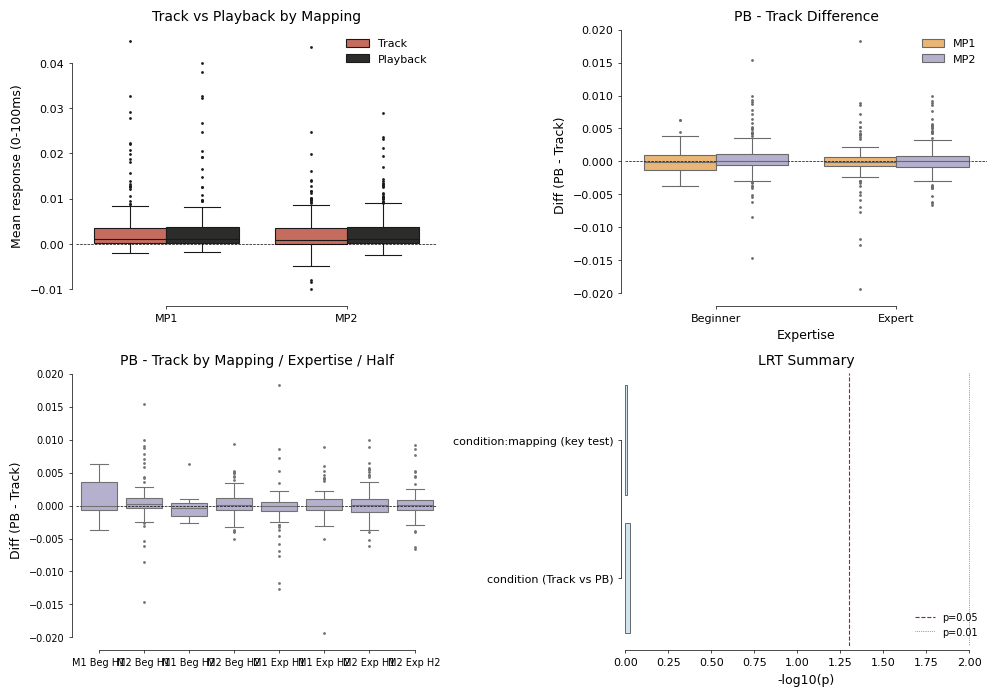


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       4039.07   -8042.14   -7953.31
  Random Intercept                         4039.07   -8042.14   -7953.31            --        --
  Random Int + Slope (condition)           4039.16   -8040.32   -7946.55        0.1769  0.674033

  -> Best model by AIC: Fixed effects only (AIC=-8042.14)

  METRIC: mean  |  WINDOW: 0-300ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 320 neurons



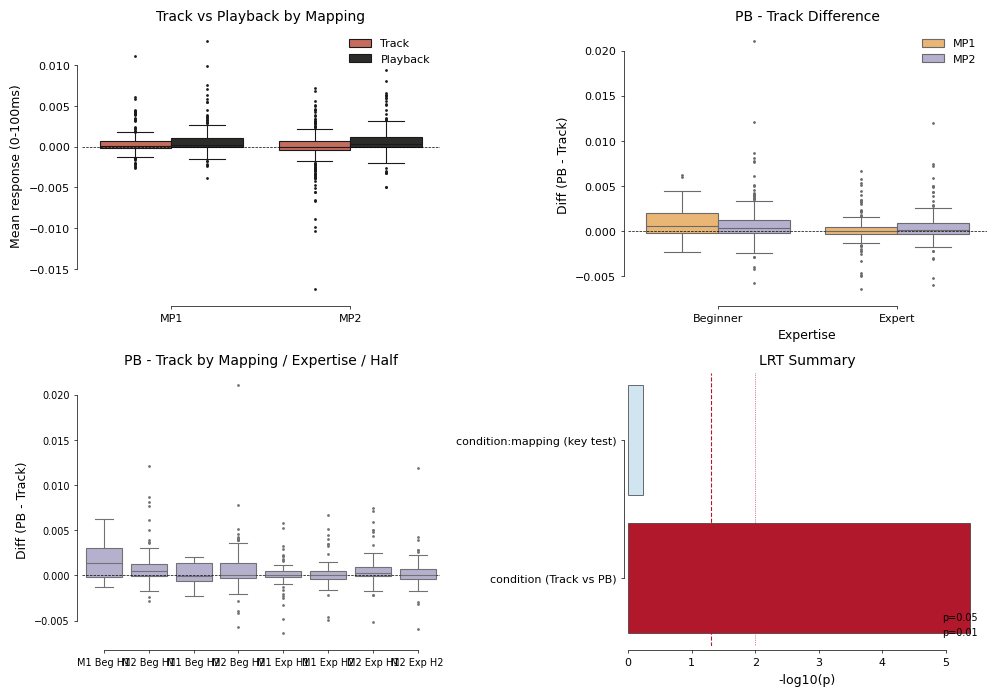


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       5018.03  -10000.07   -9911.23
  Random Intercept                         5018.03  -10000.07   -9911.23            --        --
  Random Int + Slope (condition)           5019.25  -10000.49   -9906.72        2.4250  0.119416

  -> Best model by AIC: Random Int + Slope (condition) (AIC=-10000.49)

  METRIC: mean  |  WINDOW: 0-500ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 

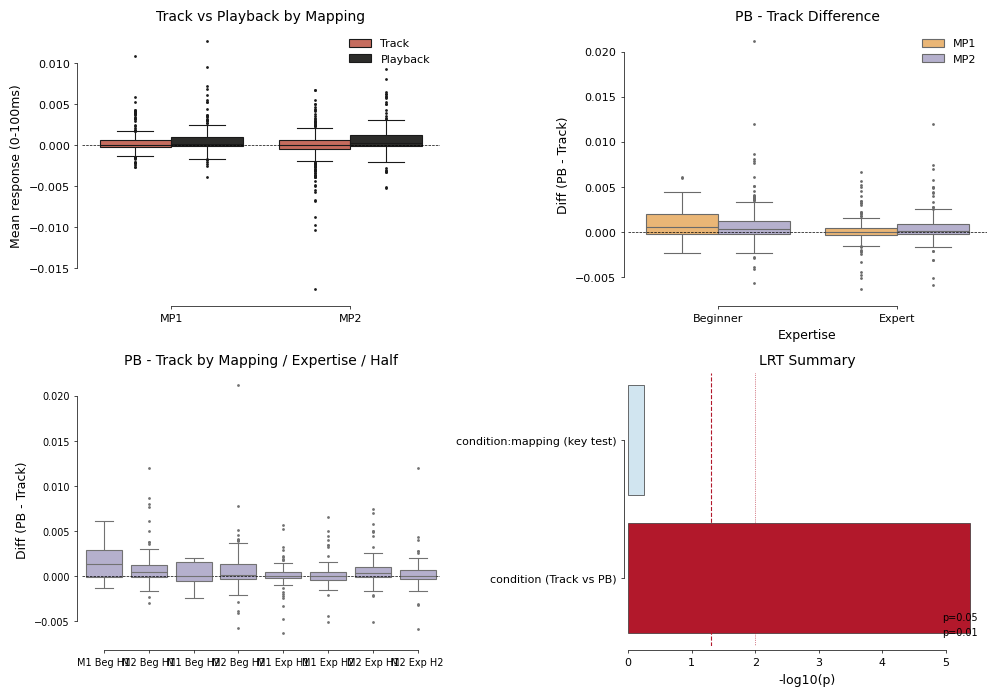


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       5029.05  -10022.10   -9933.26
  Random Intercept                         5029.05  -10022.10   -9933.26            --        --
  Random Int + Slope (condition)           5030.41  -10022.81   -9929.04        2.7134  0.099506

  -> Best model by AIC: Random Int + Slope (condition) (AIC=-10022.81)

  METRIC: peak  |  WINDOW: 0-100ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 

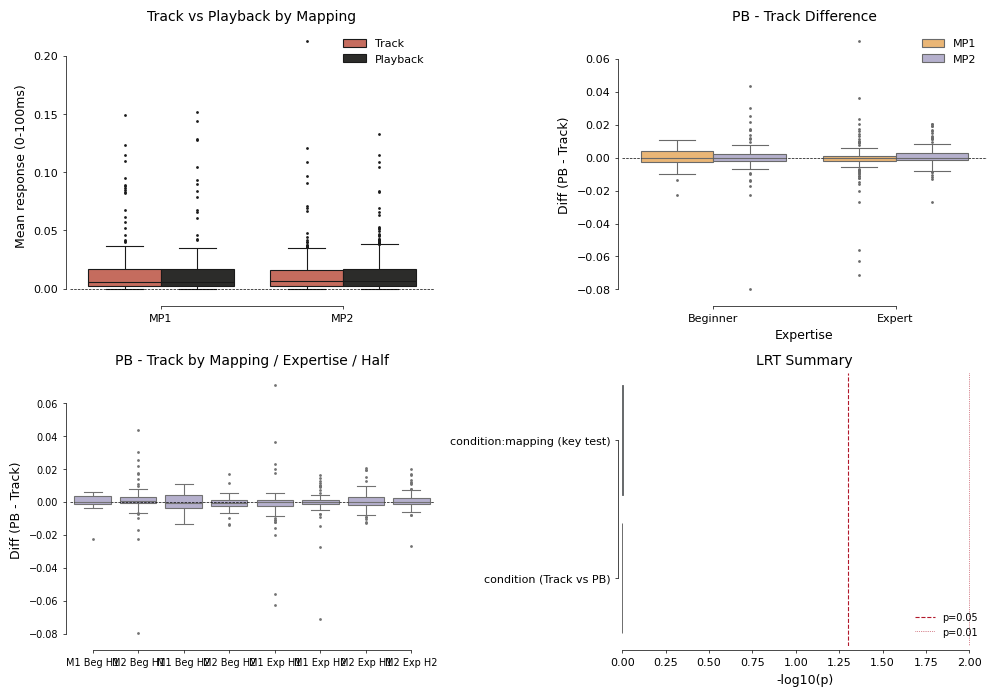


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       2591.72   -5147.44   -5058.60
  Random Intercept                         2591.72   -5147.44   -5058.60            --        --
  Random Int + Slope (condition)           2591.56   -5145.13   -5051.35        0.0000  1.000000

  -> Best model by AIC: Fixed effects only (AIC=-5147.44)

  METRIC: peak  |  WINDOW: 0-300ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 320 neurons



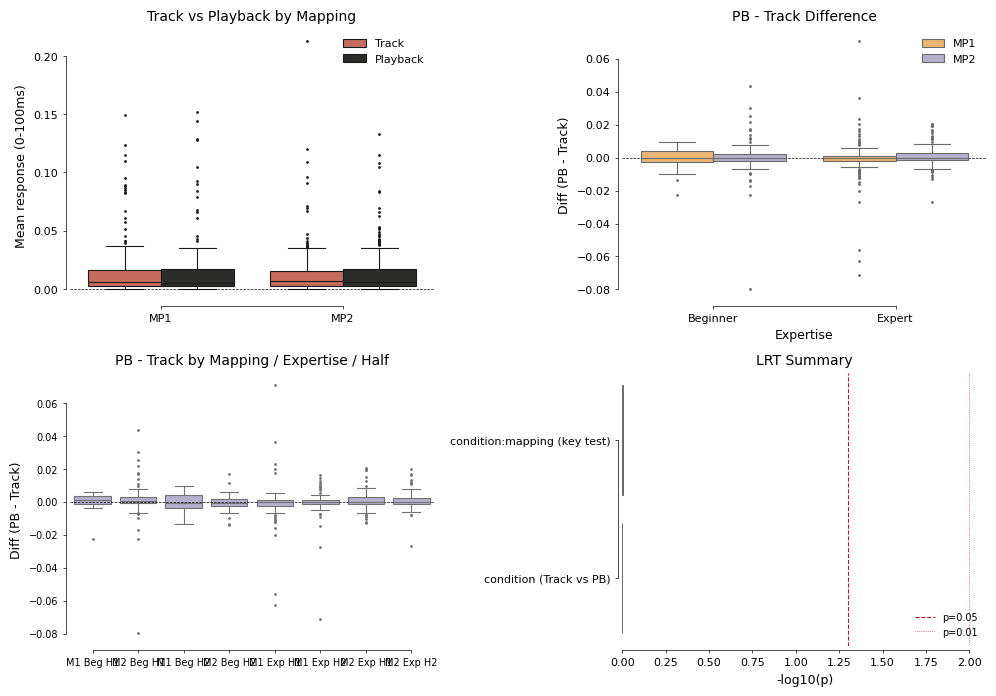


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       2593.73   -5151.46   -5062.62
  Random Intercept                         2593.73   -5151.46   -5062.62            --        --
  Random Int + Slope (condition)           2593.52   -5149.05   -5055.27        0.0000  1.000000

  -> Best model by AIC: Fixed effects only (AIC=-5151.46)

  METRIC: peak  |  WINDOW: 0-500ms
Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1028 (320 neurons x 2 conditions)
  Unique sessions: 28
    MP1: 14 sessions, 194 neurons
    MP2: 14 sessions, 320 neurons



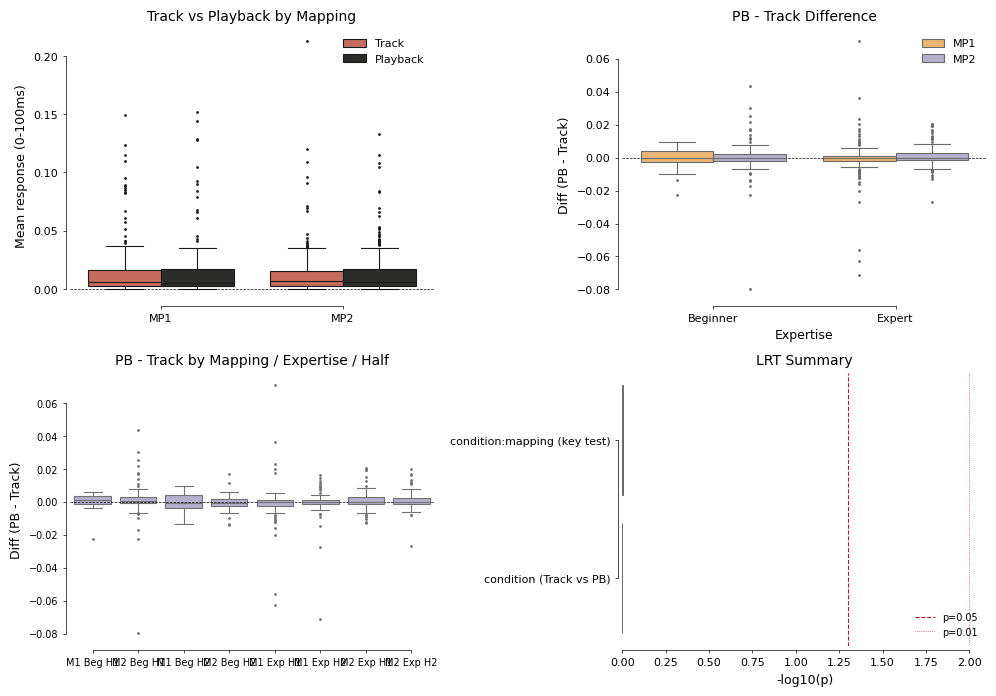


  Tip: run '%matplotlib qt' before this cell for a resizable popup window.

  RANDOM EFFECTS STRUCTURE COMPARISON

  Fitting: Fixed effects only ...
  Fitting: Random Intercept ...
  Fitting: Random Intercept + Slope for condition ...

  Model                                         LL        AIC        BIC  vs prev chi2         p
  ---------------------------------------------------------------------------------------------
  Fixed effects only                       2593.74   -5151.48   -5062.64
  Random Intercept                         2593.74   -5151.48   -5062.64            --        --
  Random Int + Slope (condition)           2593.53   -5149.06   -5055.29        0.0000  1.000000

  -> Best model by AIC: Fixed effects only (AIC=-5151.48)


In [10]:
# LMM: Track vs Playback, MP1 vs MP2
#
# Response: mean or peak amplitude (baseline-subtracted) in post-trigger window
# Fixed:    condition (Track/PB) x mapping (MP1/MP2) x expertise x half
# Random:   (1 + condition | neuron_id)

import sys
sys.path.insert(0, r'C:\Users\PenPen\Ferret\Analysis')
import importlib
import lmm_analysis
importlib.reload(lmm_analysis)
from lmm_analysis import run_lmm_analysis, compare_random_effect_structures

for metric in ["mean", "peak"]:
    for t_window, label in [(0.1, "0-100ms"), (0.3, "0-300ms"), (0.5, "0-500ms")]:
        sep = "=" * 70
        print()
        print(sep)
        print("  METRIC: " + metric + "  |  WINDOW: " + label)
        print(sep)
        result_lmm, df_lmm = run_lmm_analysis(
            traj_by_half_mp1, traj_by_half_mp2, time, save_directory,
            auc_t_start=0.0, auc_t_end=t_window, metric=metric
        )
        compare_random_effect_structures(df_lmm)

## 3. Lie Algebra / Neural Dynamics

Apply the Lie algebra generator method from `Group Theory ouput rm.ipynb` to Skieur.


In [11]:
# ==========================================
# 1. Load spike-sorted Skieur data from NAS pickles
# ==========================================
import pickle

NAS = r"\\129.199.81.18\\data5\\eTheremin"

def load_pickled_ss(file_prefix, session_type, dt):
    """Load pre-pickled spike-sorted data (same format as peak analysis)."""
    data_path = os.path.join(NAS, f"{file_prefix}_{session_type}_{dt}_data_ss")
    feat_path = os.path.join(NAS, f"{file_prefix}_{session_type}_{dt}_feature_ss")
    with open(data_path, "rb") as f:
        n_data = pickle.load(f)
    with open(feat_path, "rb") as f:
        f_data = pickle.load(f)
    return n_data, f_data


# Load playback sessions (contain both Tracking and Playback conditions)
print("Loading SKIEUR hs0 playback (spike-sorted)...")
n_data_hs0, f_data_hs0 = load_pickled_ss("SKIEUR_hs_0", "playback", dt)
print(f"  hs0: {len(n_data_hs0)} sessions")

print("Loading SKIEUR hs1 playback (spike-sorted)...")
n_data_hs1, f_data_hs1 = load_pickled_ss("SKIEUR_hs_1", "playback", dt)
print(f"  hs1: {len(n_data_hs1)} sessions")

# Add signed Velocity_x to each session (derived from Position)
for f_df in f_data_hs0 + f_data_hs1:
    pos = f_df["Position"].values
    vel = np.diff(pos)
    vel = np.append(0, vel)
    vel = vel * 100
    vel[~np.isfinite(vel)] = 0
    f_df["Velocity_x"] = vel

# Combine headstages
n_data_all_raw = list(n_data_hs0) + list(n_data_hs1)
f_data_all_raw = list(f_data_hs0) + list(f_data_hs1)
n_hs0 = len(n_data_hs0)

print(f"Total spike-sorted sessions: {len(n_data_all_raw)} (hs0={n_hs0}, hs1={len(f_data_hs1)})")

# Filter: keep only sessions with >= 10 good clusters
MIN_GC = 10
n_data_all = []
f_data_all = []
n_hs0_filtered = 0
for i, nd in enumerate(n_data_all_raw):
    n_gc = nd.shape[0]
    if n_gc >= MIN_GC:
        n_data_all.append(nd)
        f_data_all.append(f_data_all_raw[i])
        if i < n_hs0:
            n_hs0_filtered += 1

print(f"After gc >= {MIN_GC} filter: {len(n_data_all)} sessions (hs0={n_hs0_filtered}, hs1={len(n_data_all)-n_hs0_filtered})")
print(f"Removed {len(n_data_all_raw) - len(n_data_all)} sessions with < {MIN_GC} good clusters")
n_hs0 = n_hs0_filtered

# Quick validation
example = f_data_all[0]
print(f"Example session: {example.shape[0]} timepoints, gc_count={n_data_all[0].shape[0]}")
print(f"  Condition values: {example["Condition"].unique()}")
print(f"  Velocity_x range: [{example["Velocity_x"].min():.1f}, {example["Velocity_x"].max():.1f}]")

Loading SKIEUR hs0 playback (spike-sorted)...
  hs0: 14 sessions
Loading SKIEUR hs1 playback (spike-sorted)...
  hs1: 12 sessions
Total spike-sorted sessions: 26 (hs0=14, hs1=12)
After gc >= 10 filter: 13 sessions (hs0=6, hs1=7)
Removed 13 sessions with < 10 good clusters
Example session: 530545 timepoints, gc_count=12
  Condition values: [0. 1.]
  Velocity_x range: [-62.9, 90.3]


In [12]:
# ==========================================
# 2. Lie Algebra Generator Analysis
# ==========================================

def fit_lie_algebra_with_leak(r, x_dot, dt=0.005):
    """Fit dR/dt = J_skew * R * x_dot + L * R using least squares.
    Returns J_skew, skewness_ratio, R2, J_full.
    """
    T, N = r.shape
    dr_dt = np.gradient(r, dt, axis=0)
    U_rot = r * x_dot[:, np.newaxis]
    U_augmented = np.hstack([U_rot, r])

    weights_T, _, _, _ = np.linalg.lstsq(U_augmented, dr_dt, rcond=None)
    weights = weights_T.T

    J_unconstrained = weights[:, :N]
    L_leak = weights[:, N:]
    J_skew = 0.5 * (J_unconstrained - J_unconstrained.T)

    norm_total = np.linalg.norm(J_unconstrained)
    norm_skew = np.linalg.norm(J_skew)
    skewness_ratio = norm_skew / norm_total if norm_total > 1e-9 else 0

    dr_dt_pred = U_rot @ J_skew.T + r @ L_leak.T
    ss_res = np.sum((dr_dt - dr_dt_pred) ** 2)
    ss_tot = np.sum((dr_dt - np.mean(dr_dt)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-9 else 0

    return J_skew, skewness_ratio, r2, J_unconstrained


# Run on all Skieur sessions
all_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T  # (Time, Neurons)
    x_dot_full = f_df["Velocity_x"].values  # signed velocity
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        # Extract peri-event windows (+/-0.3s around Frequency_changes==1)
        trigger_mask = (conditions == val) & (f_df["Frequency_changes"].values == 1)
        trigger_indices = np.where(trigger_mask)[0]
        if len(trigger_indices) < 5:
            continue

        n_pre = int(0.3 / dt)
        n_post = int(0.3 / dt)
        windows_n, windows_l = [], []
        for ti in trigger_indices:
            t_start = ti - n_pre
            t_end = ti + n_post + 1
            if t_start >= 0 and t_end <= n_data_session.shape[1]:
                windows_n.append(r_full[t_start:t_end])
                windows_l.append(x_dot_full[t_start:t_end])

        if not windows_n:
            continue

        r_sub = np.concatenate(windows_n, axis=0)
        x_dot_sub = np.concatenate(windows_l, axis=0)

        try:
            J_skew, skew_ratio, r2, J_full = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
            all_results.append({
                "Subject": "SKIEUR",
                "Session_Idx": idx,
                "Headstage": hs_label,
                "Condition": label,
                "Skewness_Ratio": skew_ratio,
                "R2": r2,
                "N_Neurons": r_sub.shape[1],
                "N_Timepoints": r_sub.shape[0],
            })
        except Exception as e:
            print(f"Error SKIEUR session {idx} [{label}]: {e}")

results_df = pd.DataFrame(all_results)
print()
print("Analysis complete: " + str(len(results_df)) + " entries")
print(results_df.groupby(["Headstage", "Condition"])[["Skewness_Ratio", "R2"]].mean().round(4))


Analysis complete: 26 entries
                     Skewness_Ratio      R2
Headstage Condition                        
hs0       Playback           0.9096  0.0004
          Tracking           0.8868  0.0004
hs1       Playback           0.8704  0.0004
          Tracking           0.8817  0.0005


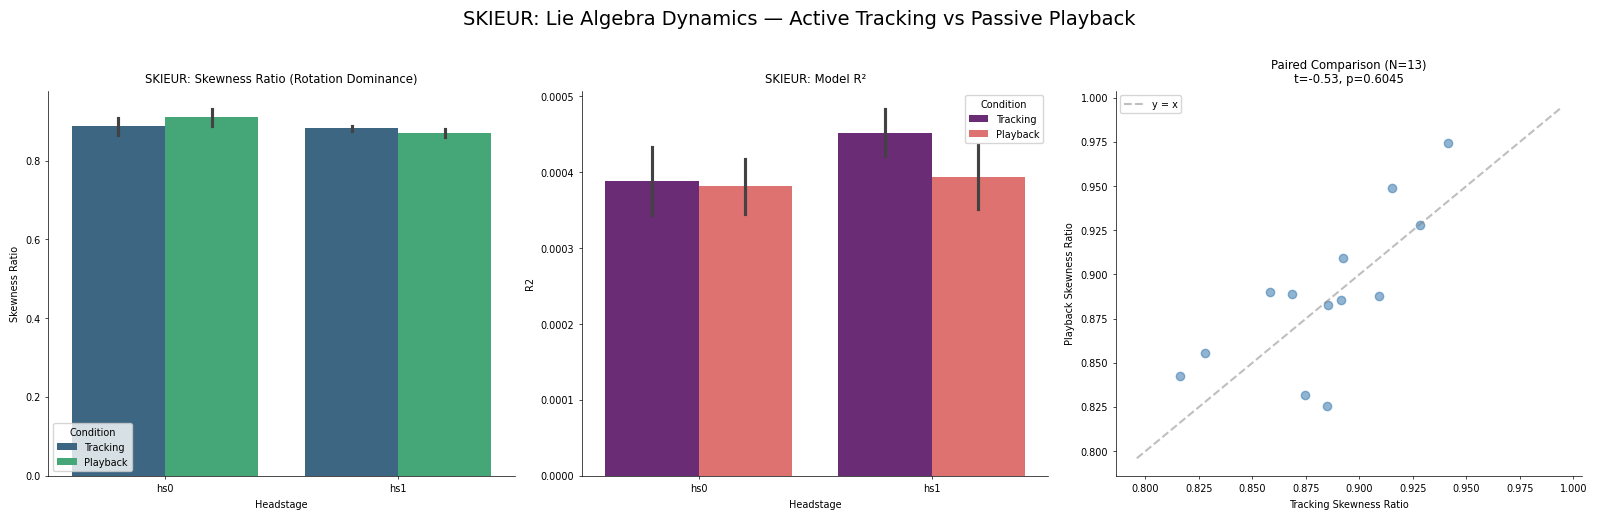

Paired t-test (N=13 pairs):
  Skewness Ratio: t=-0.532, p=0.604456
  Tracking  mean=0.8841 ± 0.0348
  Playback  mean=0.8885 ± 0.0424


In [13]:
# ==========================================
# 3. Visualization & Paired Statistics
# ==========================================
from scipy.stats import ttest_rel

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=results_df, x="Headstage", y="Skewness_Ratio", hue="Condition",
            ax=axes[0], palette="viridis", errorbar="se")
axes[0].set_title("SKIEUR: Skewness Ratio (Rotation Dominance)")
axes[0].set_ylabel("Skewness Ratio")

sns.barplot(data=results_df, x="Headstage", y="R2", hue="Condition",
            ax=axes[1], palette="magma", errorbar="se")
axes[1].set_title("SKIEUR: Model R" + chr(0x00B2))

pivot = results_df.pivot_table(
    values=["Skewness_Ratio", "R2"],
    index=["Subject", "Session_Idx", "Headstage"],
    columns="Condition"
).dropna()

t_skew, p_skew = ttest_rel(pivot["Skewness_Ratio"]["Tracking"],
                           pivot["Skewness_Ratio"]["Playback"])

tr_vals = pivot["Skewness_Ratio"]["Tracking"].values
pb_vals = pivot["Skewness_Ratio"]["Playback"].values
axes[2].scatter(tr_vals, pb_vals, alpha=0.6, c="steelblue")
lims = [min(tr_vals.min(), pb_vals.min()) - 0.02,
        max(tr_vals.max(), pb_vals.max()) + 0.02]
axes[2].plot(lims, lims, "--", color="gray", alpha=0.5, label="y = x")
axes[2].set_xlabel("Tracking Skewness Ratio")
axes[2].set_ylabel("Playback Skewness Ratio")
axes[2].set_title("Paired Comparison (N=" + str(len(pivot)) + ")\n" +
    "t=" + str(round(t_skew, 2)) + ", p=" + str(round(p_skew, 4)))
axes[2].legend()

plt.suptitle("SKIEUR: Lie Algebra Dynamics \u2014 Active Tracking vs Passive Playback",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Paired t-test (N=" + str(len(pivot)) + " pairs):")
print("  Skewness Ratio: t=" + str(round(t_skew, 3)) + ", p=" + str(round(p_skew, 6)))
print("  Tracking  mean=" + str(round(tr_vals.mean(), 4)) + " \u00b1 " + str(round(tr_vals.std(), 4)))
print("  Playback  mean=" + str(round(pb_vals.mean(), 4)) + " \u00b1 " + str(round(pb_vals.std(), 4)))

Eigenvalue paired t-test (N=13):
  |Real| (Dissipation): Tracking=0.0048, Playback=0.0066, t=-3.356, p=0.005716
  |Imag| (Rotation):    Tracking=0.2959, Playback=0.4374, t=-7.239, p=1e-05


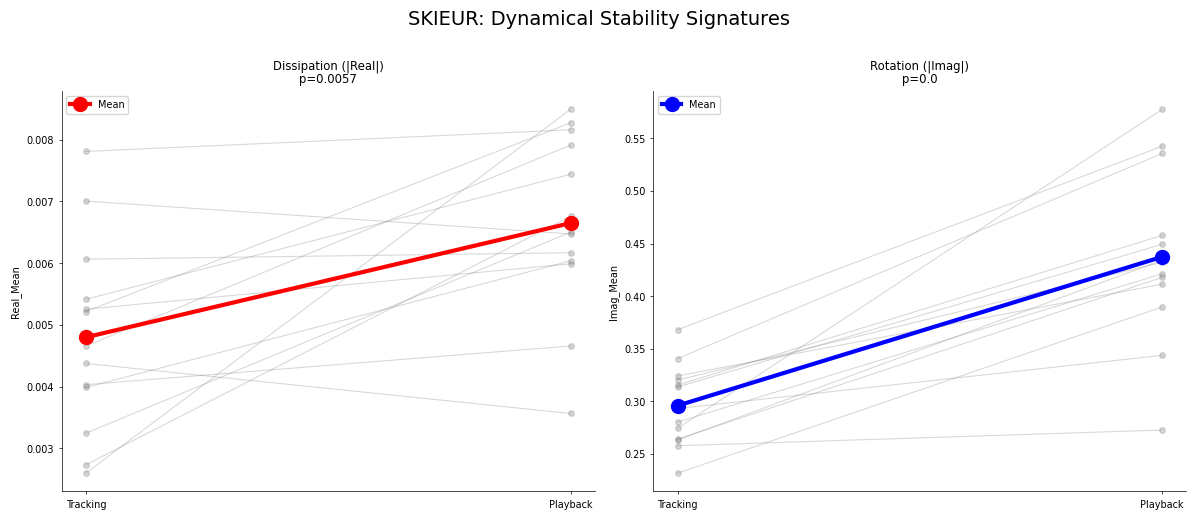

In [14]:
# ==========================================
# 4. Eigenvalue Stability Analysis
# ==========================================
min_points = 500
eig_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T
    x_dot_full = f_df["Velocity_x"].values
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        # Extract peri-event windows (+/-0.3s around Frequency_changes==1)
        trigger_mask = (conditions == val) & (f_df["Frequency_changes"].values == 1)
        trigger_indices = np.where(trigger_mask)[0]
        if len(trigger_indices) < 5:
            continue

        n_pre = int(0.3 / dt)
        n_post = int(0.3 / dt)
        windows_n, windows_l = [], []
        for ti in trigger_indices:
            t_start = ti - n_pre
            t_end = ti + n_post + 1
            if t_start >= 0 and t_end <= n_data_session.shape[1]:
                windows_n.append(r_full[t_start:t_end])
                windows_l.append(x_dot_full[t_start:t_end])

        if not windows_n:
            continue

        r_sub = np.concatenate(windows_n, axis=0)
        x_dot_sub = np.concatenate(windows_l, axis=0)

        try:
            _, _, _, J_raw = fit_lie_algebra_with_leak(r_sub, x_dot_sub)
            eigvals = np.linalg.eigvals(J_raw)
            real_mean = np.mean(np.abs(np.real(eigvals)))
            imag_mean = np.mean(np.abs(np.imag(eigvals)))
            eig_results.append({
                "Subject": "SKIEUR", "Session_Idx": idx, "Headstage": hs_label,
                "Condition": label, "Real_Mean": real_mean,
                "Imag_Mean": imag_mean,
                "Imag_Real_Ratio": imag_mean / real_mean if real_mean > 1e-9 else 0,
                "N_Neurons": r_full.shape[1],
            })
        except Exception as e:
            print(f"Eig error SKIEUR {idx} [{label}]: {e}")

eig_df = pd.DataFrame(eig_results)

pivot_eig = eig_df.pivot_table(
    values=["Real_Mean", "Imag_Mean"],
    index=["Subject", "Session_Idx", "Headstage"],
    columns="Condition"
).dropna()

t_real, p_real = ttest_rel(pivot_eig["Real_Mean"]["Tracking"], pivot_eig["Real_Mean"]["Playback"])
t_imag, p_imag = ttest_rel(pivot_eig["Imag_Mean"]["Tracking"], pivot_eig["Imag_Mean"]["Playback"])

print("Eigenvalue paired t-test (N=" + str(len(pivot_eig)) + "):")
print("  |Real| (Dissipation): Tracking=" + str(round(pivot_eig["Real_Mean"]["Tracking"].mean(), 4)) + ", Playback=" + str(round(pivot_eig["Real_Mean"]["Playback"].mean(), 4)) + ", t=" + str(round(t_real, 3)) + ", p=" + str(round(p_real, 6)))
print("  |Imag| (Rotation):    Tracking=" + str(round(pivot_eig["Imag_Mean"]["Tracking"].mean(), 4)) + ", Playback=" + str(round(pivot_eig["Imag_Mean"]["Playback"].mean(), 4)) + ", t=" + str(round(t_imag, 3)) + ", p=" + str(round(p_imag, 6)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
configs = [
    (axes[0], "Real_Mean", "Dissipation (|Real|)\n" + "p=" + str(round(p_real, 4)), p_real, "red"),
    (axes[1], "Imag_Mean", "Rotation (|Imag|)\n" + "p=" + str(round(p_imag, 4)), p_imag, "blue"),
]
for ax, col, ttl, p_val, color in configs:
    for _, row in pivot_eig.iterrows():
        ax.plot([0, 1], [row[col]["Tracking"], row[col]["Playback"]],
                "o-", color="gray", alpha=0.3, markersize=4, linewidth=0.8)
    ax.plot([0, 1], [pivot_eig[col]["Tracking"].mean(), pivot_eig[col]["Playback"].mean()],
            "o-", color=color, linewidth=3, markersize=10, label="Mean")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Tracking", "Playback"])
    ax.set_ylabel(col)
    ax.set_title(ttl)
    ax.legend()

plt.suptitle("SKIEUR: Dynamical Stability Signatures", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. 3D Manifold HTML Visualization (Plotly)
# ==========================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

try:
    import cebra
    from cebra import CEBRA
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_CEBRA = True
    print("CEBRA is available")
except ImportError:
    HAS_CEBRA = False
    print("CEBRA not installed. This cell requires: pip install cebra")

if HAS_CEBRA:

    def run_cebra_skieur(n_data_list, f_data_list, n_hs0, dt=0.005):
        """Train CEBRA on L2-normalized neural data, split by Tracking/Playback.
        Uses signed Velocity_x as labels.
        """
        results = {}
        for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
            neural_list = []
            label_list = []
            sid_list = []

            for s_idx, (n_raw, f_df) in enumerate(zip(n_data_list, f_data_list)):
                # Extract peri-event windows (±0.3s around Frequency_changes==1)
                trigger_mask = (f_df["Condition"].values == val) & (f_df["Frequency_changes"].values == 1)
                trigger_indices = np.where(trigger_mask)[0]
                if len(trigger_indices) < 5:
                    continue

                n_pre_orig = int(0.3 / dt)
                n_post_orig = int(0.3 / dt)
                windows_n, windows_l = [], []
                for ti in trigger_indices:
                    t_start = ti - n_pre_orig
                    t_end = ti + n_post_orig + 1
                    if t_start >= 0 and t_end <= n_raw.shape[1]:
                        win = n_raw[:, t_start:t_end].T.astype(np.float32)
                        lab = f_df["Velocity_x"].values[t_start:t_end].astype(np.float32)
                        windows_n.append(win)
                        windows_l.append(lab)

                if not windows_n:
                    continue

                # Concatenate trials within this session.
                # CEBRA's joint conditional sampler (time_delta + label)
                # rejects spurious edges where label jumps at trial boundaries.
                # Keeps num_sessions = original session count (e.g. 5).
                curr_n = np.concatenate(windows_n, axis=0)
                curr_l = np.concatenate(windows_l, axis=0).reshape(-1, 1)

                norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
                norms[norms == 0] = 1e-9
                curr_n_norm = curr_n / norms

                neural_list.append(curr_n_norm)
                label_list.append(curr_l)
                sid_list.append(np.full(len(curr_l), s_idx))

            if not neural_list:
                continue

            hs_counts = sum(1 for i in range(len(neural_list)) if i < n_hs0)
            print(f"  {label}: {len(neural_list)} sessions (hs0={hs_counts}, hs1={len(neural_list)-hs_counts})")

            model = CEBRA(
                model_architecture="offset10-model",
                output_dimension=3,
                max_iterations=3000,
                batch_size=512,
                learning_rate=3e-4,
                temperature=1.5,
                distance="cosine",
                conditional="time_delta",
                device="cuda",
                verbose=True
            )
            model.fit(neural_list, label_list)

            embeddings_list = []
            for i, curr_n_norm in enumerate(neural_list):
                curr_emb = model.transform(curr_n_norm, session_id=i)
                embeddings_list.append(curr_emb)

            emb_all = np.concatenate(embeddings_list, axis=0)
            results[label] = (
                emb_all,
                np.concatenate(label_list).flatten(),
                np.concatenate(sid_list)
            )
            print(f"  {label} complete.")

        return results

    def visualize_skieur_webgl(cebra_res, save_dir, downsample_factor=3):
        """Plotly WebGL 3D scatter: Tracking (left) vs Playback (right).
        Optimized: downsampling + float rounding + CDN for small HTML."""
        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{"type": "scene"}, {"type": "scene"}]],
            subplot_titles=("<b>Active Tracking (SKIEUR)</b>",
                            "<b>Passive Playback (SKIEUR)</b>")
        )

        all_embs = np.concatenate([res[0] for res in cebra_res.values()])
        axis_max = np.max(np.abs(all_embs)) * 1.1

        all_labels = np.concatenate([res[1] for res in cebra_res.values()])
        cmin = float(np.percentile(all_labels, 2))
        cmax = float(np.percentile(all_labels, 98))

        fig.add_trace(
            go.Scatter3d(
                x=[0, 0], y=[0, 0], z=[0, 0],
                mode="markers",
                marker=dict(
                    size=0.001,
                    color=[cmin, cmax],
                    colorscale="Plasma",
                    cmin=cmin, cmax=cmax,
                    showscale=True,
                    colorbar=dict(title="Velocity (signed)", x=1.05, thickness=15),
                    line=dict(width=0)
                ),
                showlegend=False, hoverinfo="skip"
            ),
            row=1, col=2
        )

        for i, cond in enumerate(["Tracking", "Playback"]):
            if cond not in cebra_res:
                continue
            emb, labels, sess_ids = cebra_res[cond]

            # In-plot downsampling for HTML size reduction
            if downsample_factor > 1:
                emb = emb[::downsample_factor]
                labels = labels[::downsample_factor]
                sess_ids = sess_ids[::downsample_factor]

            # Float precision reduction
            emb = np.round(emb, 4)
            labels_rounded = np.round(labels, 2)

            unique_sessions = np.unique(sess_ids)

            for s_id in unique_sessions:
                mask = (sess_ids == s_id)
                if not np.any(mask):
                    continue

                dynamic_size = 3 + 8 * np.abs(labels[mask]) / max(abs(cmin), abs(cmax), 1e-9)
                dynamic_size = np.round(dynamic_size, 1)

                fig.add_trace(
                    go.Scatter3d(
                        x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                        mode="markers",
                        marker=dict(
                            size=dynamic_size,
                            line=dict(width=0),
                            color=labels_rounded[mask],
                            colorscale="Plasma",
                            cmin=cmin, cmax=cmax,
                            opacity=0.4,
                            showscale=False
                        ),
                        name=f"Sess {int(s_id)}",
                        legendgroup=f"Sess {int(s_id)}",
                        showlegend=bool(i == 0)
                    ),
                    row=1, col=i + 1
                )

        scene_config = dict(
            xaxis=dict(range=[-axis_max, axis_max], visible=False),
            yaxis=dict(range=[-axis_max, axis_max], visible=False),
            zaxis=dict(range=[-axis_max, axis_max], visible=False),
            aspectmode="cube"
        )

        fig.update_layout(
            height=700,
            title_text="Shared Neural Manifold Topology: SKIEUR",
            title_x=0.5,
            scene1=scene_config,
            scene2=scene_config,
            margin=dict(l=0, r=0, b=0, t=60),
        template="plotly_white",
            legend=dict(title="Sessions", x=1.1, y=0.5)
        )

        file_name = "CEBRA_Manifold_SKIEUR_updated.html"
        save_path = os.path.join(save_dir, file_name)
        fig.write_html(save_path, include_plotlyjs='cdn')
        print(f"Saved: {save_path}")

    # ---- Sample 5 sessions chronologically, then execute CEBRA ----
    MIN_GC = 10
    N_SAMPLE = 5
    valid_idx = [i for i, nd in enumerate(n_data_all) if nd.shape[0] >= MIN_GC]

    if len(valid_idx) <= N_SAMPLE:
        chosen = valid_idx
    else:
        chosen = [valid_idx[int(round(i * (len(valid_idx) - 1) / (N_SAMPLE - 1)))] for i in range(N_SAMPLE)]
        chosen = list(dict.fromkeys(chosen))

    n_subset = [n_data_all[i] for i in chosen]
    f_subset = [f_data_all[i] for i in chosen]
    hs0_subset = sum(1 for i in chosen if i < n_hs0)

    print(f"Sampled {len(chosen)} / {len(valid_idx)} sessions (gc >= {MIN_GC}):")
    for j, i in enumerate(chosen):
        print(f"  {j+1}. session {i}: {n_data_all[i].shape[0]} neurons, {n_data_all[i].shape[1]} timepoints")

    save_directory = r"C:\\Users\\PenPen\\Desktop\\Ferret\\Results&PLots\\Web"
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
        print(f"Created: {save_directory}")

    print("=" * 60)
    print("SKIEUR 3D Manifold - signed Velocity_x, 5-session sample")
    print("Output: " + save_directory)
    print("=" * 60)

    cebra_results = run_cebra_skieur(n_subset, f_subset, hs0_subset)
    visualize_skieur_webgl(cebra_results, save_directory)

    print("Done! Open CEBRA_Manifold_SKIEUR_updated.html in a browser.")
else:
    print("Skipped: CEBRA not installed. Install with: pip install cebra")

CEBRA is available
Sampled 5 / 13 sessions (gc >= 10):
  1. session 0: 12 neurons, 530545 timepoints
  2. session 3: 15 neurons, 603243 timepoints
  3. session 6: 18 neurons, 610178 timepoints
  4. session 9: 13 neurons, 601543 timepoints
  5. session 12: 13 neurons, 607223 timepoints
SKIEUR 3D Manifold - signed Velocity_x, 5-session sample
Output: C:\\Users\\PenPen\\Desktop\\Ferret\\Results&PLots\\Web
  Tracking: 5 sessions (hs0=2, hs1=3)
  Tracking complete.
  Playback: 5 sessions (hs0=2, hs1=3)
  Playback complete.
Saved: C:\\Users\\PenPen\\Desktop\\Ferret\\Results&PLots\\Web\CEBRA_Manifold_SKIEUR_updated.html
Done! Open CEBRA_Manifold_SKIEUR_updated.html in a browser.


In [ ]:
# ============================================================
# 5. CEBRA Manifold Statistical Validation (last session only)
#
#    Data: peri-event windows (+/-0.3s around Frequency_changes==1)
#    Test 1: InfoNCE loss curve (true vs shuffled labels)
#    Test 2: k-NN external decoding R2 (held-out 20% of TRIALS)
#    Test 3: Shuffle test (np.roll — preserves temporal smoothness)
#
#    Design:
#      - Trial-level 80/20 split prevents data leakage.
#      - CEBRA.fit(train_n, train_l) with list-of-arrays API:
#        offset10-model conv kernel does NOT bleed across trial
#        boundaries (each array = independent sequence).
#      - np.roll shuffle preserves velocity power spectrum /
#        autocorrelation while breaking neural-behavior alignment.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from cebra import CEBRA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

T_PRE, T_POST = 0.3, 0.3
STEP = 5  # downsampling (GPU OOM protection)

# ---- 0. Extract peri-event windows (each = independent trial) ----
n_raw = n_data_all[-1]
f_df = f_data_all[-1]

trigger_indices = np.where(f_df["Frequency_changes"].values == 1)[0]
n_pre_orig = int(T_PRE / dt)
n_post_orig = int(T_POST / dt)

print(f"Session {len(n_data_all)-1} (last): {n_raw.shape[0]} neurons")
print(f"Total triggers (Frequency_changes==1): {len(trigger_indices)}")
print(f"Peri-event window: +/-{T_PRE}s")

windows_n, windows_l = [], []
n_skipped = 0
for idx in trigger_indices:
    start = idx - n_pre_orig
    end = idx + n_post_orig + 1
    if start >= 0 and end <= n_raw.shape[1]:
        win = n_raw[:, start:end].T[::STEP].astype(np.float32)
        lab = f_df["Velocity_x"].values[start:end][::STEP].astype(np.float32)
        windows_n.append(win)
        windows_l.append(lab)
    else:
        n_skipped += 1

# L2 normalize each trial independently
windows_n_norm = []
for win in windows_n:
    norms = np.linalg.norm(win, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9
    windows_n_norm.append(win / norms)

win_bins = windows_n_norm[0].shape[0]
n_trials = len(windows_n_norm)
total_samples = sum(len(l) for l in windows_l)
print(f"Kept {n_trials} trials, {total_samples:,} total samples")
print(f"Window: {win_bins} bins after STEP={STEP}")
print(f"Velocity range: [{min(l.min() for l in windows_l):.1f}, {max(l.max() for l in windows_l):.1f}]")

# ---- Trial-level 80/20 split (no leakage) ----
trial_indices = np.arange(n_trials)
train_idx, test_idx = train_test_split(trial_indices, test_size=0.2, random_state=42)

train_n = [windows_n_norm[i] for i in train_idx]
train_l = [windows_l[i] for i in train_idx]
test_n  = [windows_n_norm[i] for i in test_idx]
test_l  = [windows_l[i] for i in test_idx]

train_samples = sum(len(l) for l in train_l)
test_samples  = sum(len(l) for l in test_l)
print(f"Train: {len(train_n)} trials, {train_samples:,} samples")
print(f"Test:  {len(test_n)} trials, {test_samples:,} samples")

# ---- Shuffled-label control (np.roll — preserves smoothness) ----
# Cyclic shift breaks neural-behavior alignment while keeping the
# velocity power spectrum and autocorrelation intact. A stronger
# baseline than white-noise permutation.
random_shift = np.random.randint(50, 100)
train_l_shuffled = [np.roll(l, random_shift) for l in train_l]

# ---- Flatten labels for R2 scoring (needed later) ----
y_test_flat = np.concatenate(test_l)


# ============================================================
# Test 1: InfoNCE loss curves (list-of-arrays API)
# ============================================================
print()
print("=" * 60)
print("  [Test 1] InfoNCE Loss: True vs Shuffled Labels")
print("=" * 60)

# List-of-arrays API: offset10-model conv kernel respects trial
# boundaries — no spurious connections across concatenated edges.
cebra_true = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=512, distance="cosine",
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training True Label model...")
cebra_true.fit(train_n, train_l)

cebra_shuffle = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=512, distance="cosine",
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training Shuffled Label model (np.roll)...")
cebra_shuffle.fit(train_n, train_l_shuffled)

# Plot loss curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cebra_true.state_dict_['loss'], label='True Label Model', color='darkred')
ax.plot(cebra_shuffle.state_dict_['loss'], label='Shuffled Label Model (roll)', color='gray', linestyle='--')
ax.set_title("Validation 1: InfoNCE Loss Convergence\n(SKIEUR -- last session, {} train trials, list API)".format(len(train_n)))
ax.set_xlabel("Iterations")
ax.set_ylabel("InfoNCE Loss")
ax.legend()
plt.tight_layout()
plt.show()

final_loss_true = cebra_true.state_dict_['loss'][-1]
final_loss_shuffle = cebra_shuffle.state_dict_['loss'][-1]
print(f"  True model final loss:     {final_loss_true:.4f}")
print(f"  Shuffle model final loss:  {final_loss_shuffle:.4f}")


# ============================================================
# Test 2 & 3: k-NN external decoding + Shuffle test
# ============================================================
print()
print("=" * 60)
print("  [Test 2 & 3] k-NN Decoding R2 + Shuffle Baseline")
print("=" * 60)

# Transform each trial individually — CEBRA does NOT bleed
# receptive fields across trial boundaries.
print("  Projecting train/test trials into 3D manifold...")
emb_train_true = np.concatenate(
    [cebra_true.transform(n) for n in train_n], axis=0)
emb_train_shuffle = np.concatenate(
    [cebra_shuffle.transform(n) for n in train_n], axis=0)

emb_test_true = np.concatenate(
    [cebra_true.transform(n) for n in test_n], axis=0)
emb_test_shuffle = np.concatenate(
    [cebra_shuffle.transform(n) for n in test_n], axis=0)

y_train_flat = np.concatenate(train_l)
y_train_shuf_flat = np.concatenate(train_l_shuffled)

print(f"  Train embedding: {emb_train_true.shape}")
print(f"  Test embedding:  {emb_test_true.shape}")

# k-NN regressors
decoder_true = KNeighborsRegressor(n_neighbors=5, weights='distance')
decoder_shuffle = KNeighborsRegressor(n_neighbors=5, weights='distance')

decoder_true.fit(emb_train_true, y_train_flat)
decoder_shuffle.fit(emb_train_shuffle, y_train_shuf_flat)

y_pred_true = decoder_true.predict(emb_test_true)
y_pred_shuffle = decoder_shuffle.predict(emb_test_shuffle)

r2_true = r2_score(y_test_flat, y_pred_true)
r2_shuffle = r2_score(y_test_flat, y_pred_shuffle)


# ============================================================
# Report + Visualization
# ============================================================
print()
print("=" * 60)
print("       CEBRA Manifold Statistical Validation Report")
print("    (peri-event trials, trial-level 80/20 split)")
print("=" * 60)
print(f"  Session:         last ({windows_n_norm[0].shape[1]} neurons)")
print(f"  Train trials:    {len(train_n)}")
print(f"  Test trials:     {len(test_n)}")
print(f"  Window:          +/-{T_PRE}s, {win_bins} bins after STEP={STEP}")
print(f"  Train samples:   {train_samples:,}")
print(f"  Test samples:    {test_samples:,}")
print("-" * 60)
print(f"  [Test 1] True model final loss:              {final_loss_true:.4f}")
print(f"  [Test 1] Shuffle model final loss (roll):    {final_loss_shuffle:.4f}")
print(f"  [Test 2] True-label manifold decoding R2:    {r2_true:.4f}")
print(f"  [Test 3] Shuffled-label manifold decoding R2: {r2_shuffle:.4f}")
print("-" * 60)

if r2_true > 0.3 and r2_true > (r2_shuffle + 0.2):
    print("  [CONCLUSION]: Manifold validation PASSED.")
    print("  The neural population successfully encodes velocity")
    print("  in a nonlinear manifold, ruling out overfitting.")
else:
    print("  [CONCLUSION]: Manifold validation FAILED.")
    print("  True vs shuffled models show no meaningful difference.")
    print("  The manifold may be superficial or noise-driven.")
print("=" * 60)
print("  Note: single-session, trial-level split only.")
print("  Cross-session consistency requires additional testing.")

# True vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test_flat[::20], y_pred_true[::20], alpha=0.3, s=1, c='darkred')
lims = [min(y_test_flat.min(), y_pred_true.min()), max(y_test_flat.max(), y_pred_true.max())]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Velocity")
ax.set_ylabel("Predicted Velocity")
ax.set_title(f"True Label Model\nR2 = {r2_true:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_flat[::20], y_pred_shuffle[::20], alpha=0.3, s=1, c='gray')
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Velocity")
ax.set_ylabel("Predicted Velocity")
ax.set_title(f"Shuffled Label Model (np.roll)\nR2 = {r2_shuffle:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("SKIEUR: CEBRA Manifold Decoding -- True vs Predicted Velocity\n(peri-event +/-0.3s, {} trials, single last session)".format(n_trials),
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print(">>> CEBRA manifold statistical validation complete.")

Session 12 (last): 13 neurons
Total triggers (Frequency_changes==1): 7903
Peri-event window: +/-0.3s
Kept 7903 trials, 197,575 total samples
Window: 25 bins after STEP=5
Velocity range: [-70.5, 68.3]
Train: 6322 trials, 158,050 samples
Test:  1581 trials, 39,525 samples

  [Test 1] InfoNCE Loss: True vs Shuffled Labels
  Training True Label model...


  0%|          | 0/3000 [00:00<?, ?it/s]

## 4. Position-Driven Dynamics

Replaces velocity with **position** (frequency proxy) as the driver.
Equation: d**R**/dt = **J**·**R**·`x` + **L**·**R` where `x` = head position / sound frequency.


Position-driven analysis: 26 entries
                     Skewness_Ratio      R2
Headstage Condition                        
hs0       Playback           0.8931  0.0001
          Tracking           0.8799 -0.0004
hs1       Playback           0.8616 -0.0001
          Tracking           0.8648 -0.0004

  Velocity-driven vs Position-driven Skewness Ratio

  Driver       Condition     Skewness (mean)    R2 (mean)
  -------------------------------------------------------
  Velocity     Tracking      0.8841            0.0004
  Velocity     Playback      0.8885            0.0004
  Position     Tracking      0.8718            -0.0004
  Position     Playback      0.8762            0.0000

Position-driven paired t-test (N=13):
  t=-0.632, p=0.539189
  Tracking  Skewness: 0.8718 +/- 0.0515
  Playback  Skewness: 0.8762 +/- 0.0454


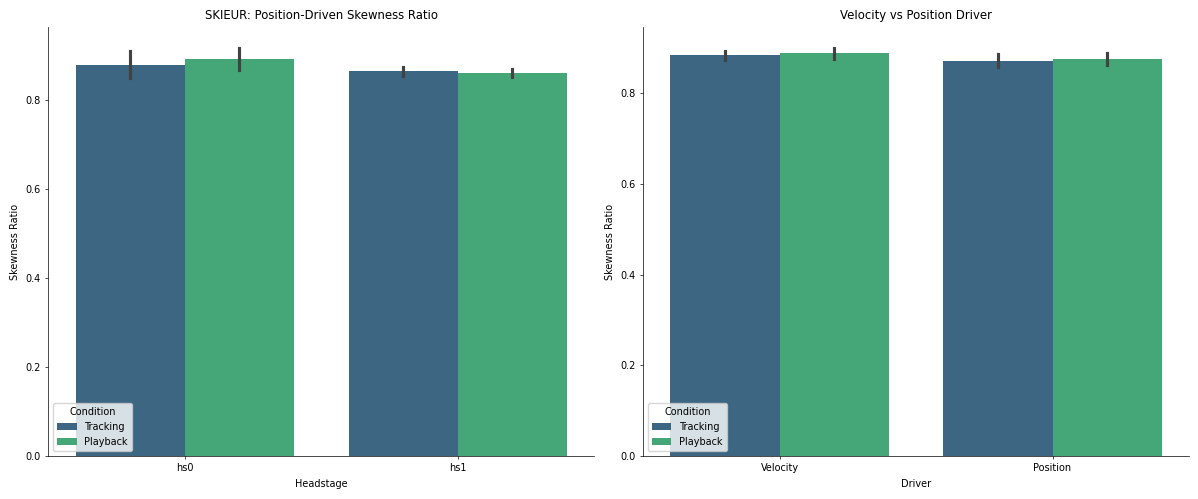

In [18]:
# ==========================================
# 4.1 Position-Driven Lie Algebra
# ==========================================

# Reuse the same fit function, but drive with Position instead of Velocity
# dR/dt = J * R * x + L * R

pos_results = []

for idx, (n_data_session, f_df) in enumerate(zip(n_data_all, f_data_all)):
    r_full = n_data_session.T
    x_full = f_df["Position"].values  # position as driver
    conditions = f_df["Condition"].values
    hs_label = "hs0" if idx < n_hs0 else "hs1"

    for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
        # Extract peri-event windows (+/-0.3s around Frequency_changes==1)
        trigger_mask = (conditions == val) & (f_df["Frequency_changes"].values == 1)
        trigger_indices = np.where(trigger_mask)[0]
        if len(trigger_indices) < 5:
            continue

        n_pre = int(0.3 / dt)
        n_post = int(0.3 / dt)
        windows_n, windows_l = [], []
        for ti in trigger_indices:
            t_start = ti - n_pre
            t_end = ti + n_post + 1
            if t_start >= 0 and t_end <= n_data_session.shape[1]:
                windows_n.append(r_full[t_start:t_end])
                windows_l.append(x_full[t_start:t_end])

        if not windows_n:
            continue

        r_sub = np.concatenate(windows_n, axis=0)
        x_sub = np.concatenate(windows_l, axis=0)

        try:
            J_skew, skew_ratio, r2, J_full = fit_lie_algebra_with_leak(r_sub, x_sub)
            pos_results.append({
                "Subject": "SKIEUR",
                "Session_Idx": idx,
                "Headstage": hs_label,
                "Condition": label,
                "Skewness_Ratio": skew_ratio,
                "R2": r2,
                "N_Neurons": r_sub.shape[1],
            })
        except Exception as e:
            print(f"Error SKIEUR {idx} [{label}]: {e}")

pos_df = pd.DataFrame(pos_results)
print("Position-driven analysis: " + str(len(pos_df)) + " entries")
print(pos_df.groupby(["Headstage", "Condition"])[["Skewness_Ratio", "R2"]].mean().round(4))

# ---- Comparison: Velocity vs Position ----
print()
print("=" * 65)
print("  Velocity-driven vs Position-driven Skewness Ratio")
print("=" * 65)
# Velocity results are in results_df
print()
print("  Driver       Condition     Skewness (mean)    R2 (mean)")
print("  " + "-" * 55)
for driver, df in [("Velocity", results_df), ("Position", pos_df)]:
    for cond in ["Tracking", "Playback"]:
        subset = df[df["Condition"] == cond]
        if len(subset) > 0:
            sk = subset["Skewness_Ratio"].mean()
            r2 = subset["R2"].mean()
            print("  {:<12s} {:<12s}  {:.4f}            {:.4f}".format(driver, cond, sk, r2))

# Paired t-test for position-driven
from scipy.stats import ttest_rel
pivot_pos = pos_df.pivot_table(
    values=["Skewness_Ratio", "R2"],
    index=["Subject", "Session_Idx", "Headstage"],
    columns="Condition"
).dropna()

t_pos, p_pos = ttest_rel(pivot_pos["Skewness_Ratio"]["Tracking"],
                          pivot_pos["Skewness_Ratio"]["Playback"])
print()
print("Position-driven paired t-test (N=" + str(len(pivot_pos)) + "):")
print("  t={:.3f}, p={:.6f}".format(t_pos, p_pos))
print("  Tracking  Skewness: {:.4f} +/- {:.4f}".format(pivot_pos["Skewness_Ratio"]["Tracking"].mean(), pivot_pos["Skewness_Ratio"]["Tracking"].std()))
print("  Playback  Skewness: {:.4f} +/- {:.4f}".format(pivot_pos["Skewness_Ratio"]["Playback"].mean(), pivot_pos["Skewness_Ratio"]["Playback"].std()))

# Barplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=pos_df, x="Headstage", y="Skewness_Ratio", hue="Condition",
            ax=axes[0], palette="viridis", errorbar="se")
axes[0].set_title("SKIEUR: Position-Driven Skewness Ratio")
axes[0].set_ylabel("Skewness Ratio")

# Overlay velocity vs position tracking means
drivers = []
for driver, df in [("Velocity", results_df), ("Position", pos_df)]:
    for _, row in df.iterrows():
        drivers.append({"Driver": driver, "Condition": row["Condition"], "Skewness_Ratio": row["Skewness_Ratio"]})
driver_df = pd.DataFrame(drivers)
sns.barplot(data=driver_df, x="Driver", y="Skewness_Ratio", hue="Condition",
            ax=axes[1], palette="viridis", errorbar="se")
axes[1].set_title("Velocity vs Position Driver")
axes[1].set_ylabel("Skewness Ratio")
plt.tight_layout()
plt.show()

In [ ]:
    # ==========================================
    # 4.2 Position-Driven CEBRA 3D Manifold
    # ==========================================
    import os
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

    if HAS_CEBRA:

        def run_cebra_position(n_data_list, f_data_list, n_hs0):
            """Train CEBRA on L2-normalized data with Position as label."""
            results = {}
            for val, label in [(0.0, "Tracking"), (1.0, "Playback")]:
                neural_list = []
                label_list = []
                sid_list = []

                for s_idx, (n_raw, f_df) in enumerate(zip(n_data_list, f_data_list)):
                    # Extract peri-event windows (±0.3s around Frequency_changes==1)
                    trigger_mask = (f_df["Condition"].values == val) & (f_df["Frequency_changes"].values == 1)
                    trigger_indices = np.where(trigger_mask)[0]
                    if len(trigger_indices) < 5:
                        continue

                    n_pre_orig = int(0.3 / dt)
                    n_post_orig = int(0.3 / dt)
                    windows_n, windows_l = [], []
                    for ti in trigger_indices:
                        t_start = ti - n_pre_orig
                        t_end = ti + n_post_orig + 1
                        if t_start >= 0 and t_end <= n_raw.shape[1]:
                            win = n_raw[:, t_start:t_end].T.astype(np.float32)
                            lab = f_df["Position"].values[t_start:t_end].astype(np.float32)
                            windows_n.append(win)
                            windows_l.append(lab)

                    if not windows_n:
                        continue

                    # Concatenate trials within this session.
                    # CEBRA's joint conditional sampler (time_delta + label)
                    # rejects spurious edges where label jumps at trial boundaries.
                    curr_n = np.concatenate(windows_n, axis=0)
                    curr_l = np.concatenate(windows_l, axis=0).reshape(-1, 1)

                    norms = np.linalg.norm(curr_n, axis=1, keepdims=True)
                    norms[norms == 0] = 1e-9
                    curr_n_norm = curr_n / norms

                    neural_list.append(curr_n_norm)
                    label_list.append(curr_l)
                    sid_list.append(np.full(len(curr_l), s_idx))

                if not neural_list:
                    continue

                model = CEBRA(
                    model_architecture="offset10-model",
                    output_dimension=3,
                    max_iterations=3000,
                    batch_size=512,
                    learning_rate=3e-4,
                    temperature=1.5,
                    distance="cosine",
                    conditional="time_delta",
                    device="cuda",
                    verbose=True
                )
                model.fit(neural_list, label_list)

                embeddings_list = []
                for i, curr_n_norm in enumerate(neural_list):
                    curr_emb = model.transform(curr_n_norm, session_id=i)
                    embeddings_list.append(curr_emb)

                emb_all = np.concatenate(embeddings_list, axis=0)
                results[label] = (
                    emb_all,
                    np.concatenate(label_list).flatten(),
                    np.concatenate(sid_list)
                )
                print(f"  {label} complete.")

            return results


        def visualize_position_webgl(cebra_res, save_dir, downsample_factor=3):
        """Plotly WebGL 3D with Position coloring. Optimized for small HTML."""
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots

        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{"type": "scene"}, {"type": "scene"}]],
            subplot_titles=("<b>Active Tracking</b>",
                            "<b>Passive Playback</b>")
        )

        all_embs = np.concatenate([res[0] for res in cebra_res.values()])
        axis_max = np.max(np.abs(all_embs)) * 1.1

        all_labels = np.concatenate([res[1] for res in cebra_res.values()])
        cmin = float(np.percentile(all_labels, 2))
        cmax = float(np.percentile(all_labels, 98))

        fig.add_trace(
            go.Scatter3d(
                x=[0, 0], y=[0, 0], z=[0, 0],
                mode="markers",
                marker=dict(
                    size=0.001,
                    color=[cmin, cmax],
                    colorscale="Plasma",
                    cmin=cmin, cmax=cmax,
                    showscale=True,
                    colorbar=dict(title="Position (cm)", x=1.05, thickness=15),
                    line=dict(width=0)
                ),
                showlegend=False, hoverinfo="skip"
            ),
            row=1, col=2
        )

        for i, cond in enumerate(["Tracking", "Playback"]):
            if cond not in cebra_res:
                continue
            emb, labels, sess_ids = cebra_res[cond]

            # In-plot downsampling for HTML size reduction
            if downsample_factor > 1:
                emb = emb[::downsample_factor]
                labels = labels[::downsample_factor]
                sess_ids = sess_ids[::downsample_factor]

            # Float precision reduction
            emb = np.round(emb, 4)
            labels_rounded = np.round(labels, 2)

            unique_sessions = np.unique(sess_ids)

            for s_id in unique_sessions:
                mask = (sess_ids == s_id)
                if not np.any(mask):
                    continue

                dynamic_size = 3 + 6 * np.abs(labels[mask] - np.median(labels)) / max(abs(cmin), abs(cmax), 1e-9)
                dynamic_size = np.round(dynamic_size, 1)

                fig.add_trace(
                    go.Scatter3d(
                        x=emb[mask, 0], y=emb[mask, 1], z=emb[mask, 2],
                        mode="markers",
                        marker=dict(
                            size=dynamic_size,
                            color=labels_rounded[mask],
                            colorscale="Plasma",
                            cmin=cmin, cmax=cmax,
                            opacity=0.25,
                            line=dict(width=0),
                            showscale=False
                        ),
                        name=f"Sess {int(s_id)}",
                        legendgroup=f"Sess {int(s_id)}",
                        showlegend=bool(i == 0)
                    ),
                    row=1, col=i + 1
                )

        scene_config = dict(
            xaxis=dict(range=[-axis_max, axis_max], visible=False),
            yaxis=dict(range=[-axis_max, axis_max], visible=False),
            zaxis=dict(range=[-axis_max, axis_max], visible=False),
            aspectmode="cube"
        )

        fig.update_layout(
            height=700,
            title_text="Neural Manifold (Position-Driven): SKIEUR",
            title_x=0.5,
            scene1=scene_config,
            scene2=scene_config,
            margin=dict(l=0, r=0, b=0, t=60),
        template="plotly_white",
            legend=dict(title="Sessions", x=1.1, y=0.5)
        )

        file_name = "CEBRA_Manifold_Position_SKIEUR.html"
        save_path = os.path.join(save_dir, file_name)
        fig.write_html(save_path, include_plotlyjs='cdn')
        print(f"Saved: {save_path}")


        # ---- Sample & Execute ----
        MIN_GC = 10
        N_SAMPLE = 5
        valid_idx = [i for i, nd in enumerate(n_data_all) if nd.shape[0] >= MIN_GC]
        if len(valid_idx) <= N_SAMPLE:
            chosen = valid_idx
        else:
            chosen = [valid_idx[int(round(i * (len(valid_idx) - 1) / (N_SAMPLE - 1)))] for i in range(N_SAMPLE)]
            chosen = list(dict.fromkeys(chosen))

        n_subset = [n_data_all[i] for i in chosen]
        f_subset = [f_data_all[i] for i in chosen]
        hs0_subset = sum(1 for i in chosen if i < n_hs0)

        print(f"Sampled {len(chosen)} sessions")
        for j, i in enumerate(chosen):
            print(f"  {j+1}. session {i}: {n_data_all[i].shape[0]} neurons")

        save_directory = r"C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web"
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)

        print("=" * 60)
        print("SKIEUR 3D Manifold - Position-Driven")
        print("=" * 60)

        cebra_pos_results = run_cebra_position(n_subset, f_subset, hs0_subset)
        visualize_position_webgl(cebra_pos_results, save_directory)

        print("Done! Open CEBRA_Manifold_Position_SKIEUR.html")
    else:
        print("Skipped: CEBRA not installed.")

Sampled 5 sessions
  1. session 0: 12 neurons
  2. session 3: 15 neurons
  3. session 6: 18 neurons
  4. session 9: 13 neurons
  5. session 12: 13 neurons
SKIEUR 3D Manifold - Position-Driven
  Tracking complete.
  Playback complete.
Saved: C:\Users\PenPen\Desktop\Ferret\Results&PLots\Web\CEBRA_Manifold_Position_SKIEUR.html
Done! Open CEBRA_Manifold_Position_SKIEUR.html


In [ ]:
# ============================================================
# 6. CEBRA Manifold Statistical Validation -- Position-Driven
#
#    Data: peri-event windows (+/-0.3s around Frequency_changes==1)
#    Label: Position (frequency proxy)
#    Test 1: InfoNCE loss curve (true vs shuffled labels)
#    Test 2: k-NN external decoding R2 (held-out 20% of TRIALS)
#    Test 3: Shuffle test (np.roll — preserves temporal smoothness)
#
#    Design:
#      - Trial-level 80/20 split prevents data leakage.
#      - CEBRA.fit(train_n, train_l) with list-of-arrays API keeps
#        conv receptive field within each trial.
#      - np.roll shuffle preserves Position power spectrum while
#        breaking neural-behavior alignment.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from cebra import CEBRA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

T_PRE, T_POST = 0.3, 0.3
STEP = 5  # downsampling (GPU OOM protection)

# ---- 0. Extract peri-event windows (each = independent trial) ----
n_raw = n_data_all[-1]
f_df = f_data_all[-1]

trigger_indices = np.where(f_df["Frequency_changes"].values == 1)[0]
n_pre_orig = int(T_PRE / dt)
n_post_orig = int(T_POST / dt)

print(f"Session {len(n_data_all)-1} (last): {n_raw.shape[0]} neurons")
print(f"Total triggers: {len(trigger_indices)}")
print(f"Label: Position (frequency proxy)")
print(f"Peri-event window: +/-{T_PRE}s")

windows_n, windows_l = [], []
n_skipped = 0
for idx in trigger_indices:
    start = idx - n_pre_orig
    end = idx + n_post_orig + 1
    if start >= 0 and end <= n_raw.shape[1]:
        win = n_raw[:, start:end].T[::STEP].astype(np.float32)
        lab = f_df["Position"].values[start:end][::STEP].astype(np.float32)
        windows_n.append(win)
        windows_l.append(lab)
    else:
        n_skipped += 1

# L2 normalize each trial independently
windows_n_norm = []
for win in windows_n:
    norms = np.linalg.norm(win, axis=1, keepdims=True)
    norms[norms == 0] = 1e-9
    windows_n_norm.append(win / norms)

win_bins = windows_n_norm[0].shape[0]
n_trials = len(windows_n_norm)
total_samples = sum(len(l) for l in windows_l)
print(f"Kept {n_trials} trials, {total_samples:,} total samples")
print(f"Window: {win_bins} bins after STEP={STEP}")
print(f"Position range: [{min(l.min() for l in windows_l):.1f}, {max(l.max() for l in windows_l):.1f}]")

# ---- Trial-level 80/20 split (no leakage) ----
trial_indices = np.arange(n_trials)
train_idx, test_idx = train_test_split(trial_indices, test_size=0.2, random_state=42)

train_n = [windows_n_norm[i] for i in train_idx]
train_l = [windows_l[i] for i in train_idx]
test_n  = [windows_n_norm[i] for i in test_idx]
test_l  = [windows_l[i] for i in test_idx]

train_samples = sum(len(l) for l in train_l)
test_samples  = sum(len(l) for l in test_l)
print(f"Train: {len(train_n)} trials, {train_samples:,} samples")
print(f"Test:  {len(test_n)} trials, {test_samples:,} samples")

# ---- Shuffled-label control (np.roll — preserves smoothness) ----
random_shift = np.random.randint(50, 100)
train_l_shuffled = [np.roll(l, random_shift) for l in train_l]

# ---- Flatten labels for R2 scoring ----
y_test_flat = np.concatenate(test_l)


# ============================================================
# Test 1: InfoNCE loss curves (list-of-arrays API)
# ============================================================
print()
print("=" * 60)
print("  [Test 1] InfoNCE Loss: True vs Shuffled Labels")
print("=" * 60)

cebra_true = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=512, distance="cosine",
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training True Label model (Position)...")
cebra_true.fit(train_n, train_l)

cebra_shuffle = CEBRA(
    model_architecture="offset10-model", output_dimension=3,
    max_iterations=3000, batch_size=512, distance="cosine",
    conditional="time_delta", device="cuda", verbose=True
)
print("  Training Shuffled Label model (np.roll)...")
cebra_shuffle.fit(train_n, train_l_shuffled)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cebra_true.state_dict_['loss'], label='True Label Model', color='darkred')
ax.plot(cebra_shuffle.state_dict_['loss'], label='Shuffled Label Model (roll)', color='gray', linestyle='--')
ax.set_title("Validation 1: InfoNCE Loss Convergence\n(SKIEUR -- last session, {} train trials, Position label)".format(len(train_n)))
ax.set_xlabel("Iterations")
ax.set_ylabel("InfoNCE Loss")
ax.legend()
plt.tight_layout()
plt.show()

final_loss_true = cebra_true.state_dict_['loss'][-1]
final_loss_shuffle = cebra_shuffle.state_dict_['loss'][-1]
print(f"  True model final loss:     {final_loss_true:.4f}")
print(f"  Shuffle model final loss:  {final_loss_shuffle:.4f}")


# ============================================================
# Test 2 & 3: k-NN external decoding + Shuffle test
# ============================================================
print()
print("=" * 60)
print("  [Test 2 & 3] k-NN Decoding R2 + Shuffle Baseline")
print("=" * 60)

print("  Projecting train/test trials into 3D manifold...")
emb_train_true = np.concatenate(
    [cebra_true.transform(n) for n in train_n], axis=0)
emb_train_shuffle = np.concatenate(
    [cebra_shuffle.transform(n) for n in train_n], axis=0)

emb_test_true = np.concatenate(
    [cebra_true.transform(n) for n in test_n], axis=0)
emb_test_shuffle = np.concatenate(
    [cebra_shuffle.transform(n) for n in test_n], axis=0)

y_train_flat = np.concatenate(train_l)
y_train_shuf_flat = np.concatenate(train_l_shuffled)

print(f"  Train embedding: {emb_train_true.shape}")
print(f"  Test embedding:  {emb_test_true.shape}")

decoder_true = KNeighborsRegressor(n_neighbors=5, weights='distance')
decoder_shuffle = KNeighborsRegressor(n_neighbors=5, weights='distance')

decoder_true.fit(emb_train_true, y_train_flat)
decoder_shuffle.fit(emb_train_shuffle, y_train_shuf_flat)

y_pred_true = decoder_true.predict(emb_test_true)
y_pred_shuffle = decoder_shuffle.predict(emb_test_shuffle)

r2_true = r2_score(y_test_flat, y_pred_true)
r2_shuffle = r2_score(y_test_flat, y_pred_shuffle)


# ============================================================
# Report + Visualization
# ============================================================
print()
print("=" * 60)
print("    CEBRA Manifold Statistical Validation Report")
print("         (Position-Driven, trial-level split)")
print("=" * 60)
print(f"  Session:         last ({windows_n_norm[0].shape[1]} neurons)")
print(f"  Label:           Position (frequency proxy)")
print(f"  Train trials:    {len(train_n)}")
print(f"  Test trials:     {len(test_n)}")
print(f"  Window:          +/-{T_PRE}s, {win_bins} bins after STEP={STEP}")
print(f"  Train samples:   {train_samples:,}")
print(f"  Test samples:    {test_samples:,}")
print("-" * 60)
print(f"  [Test 1] True model final loss:              {final_loss_true:.4f}")
print(f"  [Test 1] Shuffle model final loss (roll):    {final_loss_shuffle:.4f}")
print(f"  [Test 2] True-label manifold decoding R2:    {r2_true:.4f}")
print(f"  [Test 3] Shuffled-label manifold decoding R2: {r2_shuffle:.4f}")
print("-" * 60)

if r2_true > 0.3 and r2_true > (r2_shuffle + 0.2):
    print("  [CONCLUSION]: Manifold validation PASSED.")
else:
    print("  [CONCLUSION]: Manifold validation FAILED.")
print("=" * 60)

# True vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test_flat[::20], y_pred_true[::20], alpha=0.3, s=1, c='darkred')
lims = [min(y_test_flat.min(), y_pred_true.min()), max(y_test_flat.max(), y_pred_true.max())]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Position")
ax.set_ylabel("Predicted Position")
ax.set_title(f"True Label Model\nR2 = {r2_true:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

ax = axes[1]
ax.scatter(y_test_flat[::20], y_pred_shuffle[::20], alpha=0.3, s=1, c='gray')
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlabel("True Position")
ax.set_ylabel("Predicted Position")
ax.set_title(f"Shuffled Label Model (np.roll)\nR2 = {r2_shuffle:.4f}")
ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("SKIEUR: CEBRA Manifold Decoding -- True vs Predicted Position\n(peri-event +/-0.3s, {} trials, single last session)".format(n_trials),
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print()
print(">>> Position-driven CEBRA manifold validation complete.")

NameError: name 'n_data_all' is not defined